In [ ]:
# Install the Ultralytics package
!pip install ultralytics -q
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load the extra-large YOLO26 model
# It will automatically download the weights if not present
model = YOLO('yolo11x.pt')

# Run detection on your uploaded video
# 'save=True' saves the resulting video with bounding boxes
results = model.predict(source='/content/Video_Generation_With_Static_Camera.mp4', save=True, conf=0.25)

print("Processing complete! Check the 'runs/detect/predict' folder for your video.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/192) /content/Video_Generation_With_Static_Camera.mp4: 640x384 (no detections), 2336.9ms
video 1/1 (frame 2/192) /content/Video_Generation_With_Static_Camera.mp4: 640x384 (no detections), 2388.0ms
video 1/1 (frame 3/192) /content/Video_Generation_With_Static_Camera.mp4: 640x384 (no detections), 2225.2ms
video 1/1 (frame 4/192) /content/Video_Generation_With_Static_Camera.mp4: 640x384 (no detections), 3081.2ms
video 1/1 (frame 5/192) /c

In [ ]:
best_classes = []
best_prob = 0
best_result = 0
for result in results:

    probs = 0
    classes = []
    if result.boxes:
        # Iterate through every detected box in the frame
        for box in result.boxes:
            # Get the confidence score (probability)
            confidence = box.conf.item()
            if confidence > 0.7:
              probs += confidence

              # Get the class ID (label)
              class_id = int(box.cls.item())
              classes.append(class_id)
              # print(f"Object: {class_id} | Confidence: {confidence:.2f}")

    if probs > best_prob:

            best_result = result
            best_prob = probs
            best_classes = np.array(classes)

In [ ]:
if np.unique(best_classes).shape[0] == 1:
  if len(best_classes) > 1:
    print(f"Objects found in the image: {len(best_classes)} {results[0].names[best_classes[0]]}s")
  else:
    print(f"Object found in the image: {results[0].names[best_classes[0]]}")
else:
  for obj in best_classes:
    print(f"Object found in the image: {results[0].names[obj]}")

Object found in the image: bird


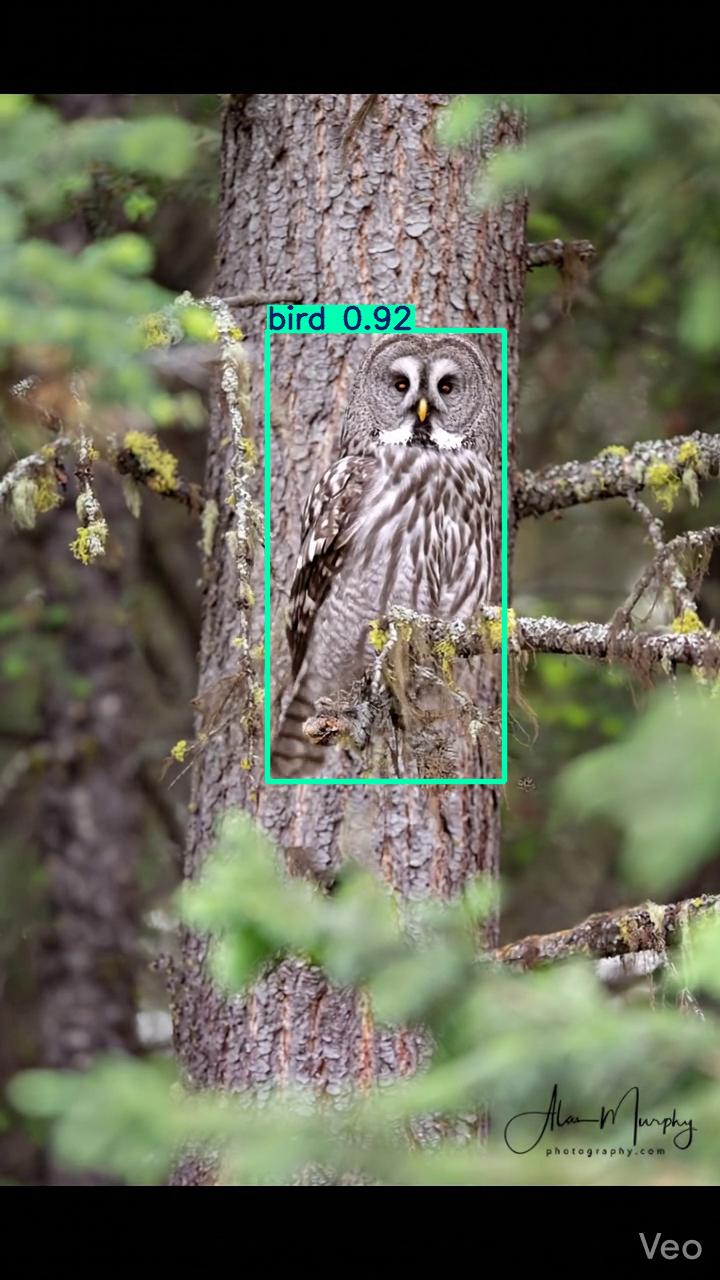

In [ ]:
best_result.show()

In [ ]:
if np.unique(best_classes).shape[0] == 1:
  if len(best_classes) > 1:
    print(f"Objects found in the image: {len(best_classes)} {results[0].names[best_classes[0]]}s")
  else:
    print(f"Object found in the image: {results[0].names[best_classes[0]]}")
else:
  for obj in best_classes:
    print(f"Object found in the image: {results[0].names[obj]}")

Objects found in the image: 3 horses


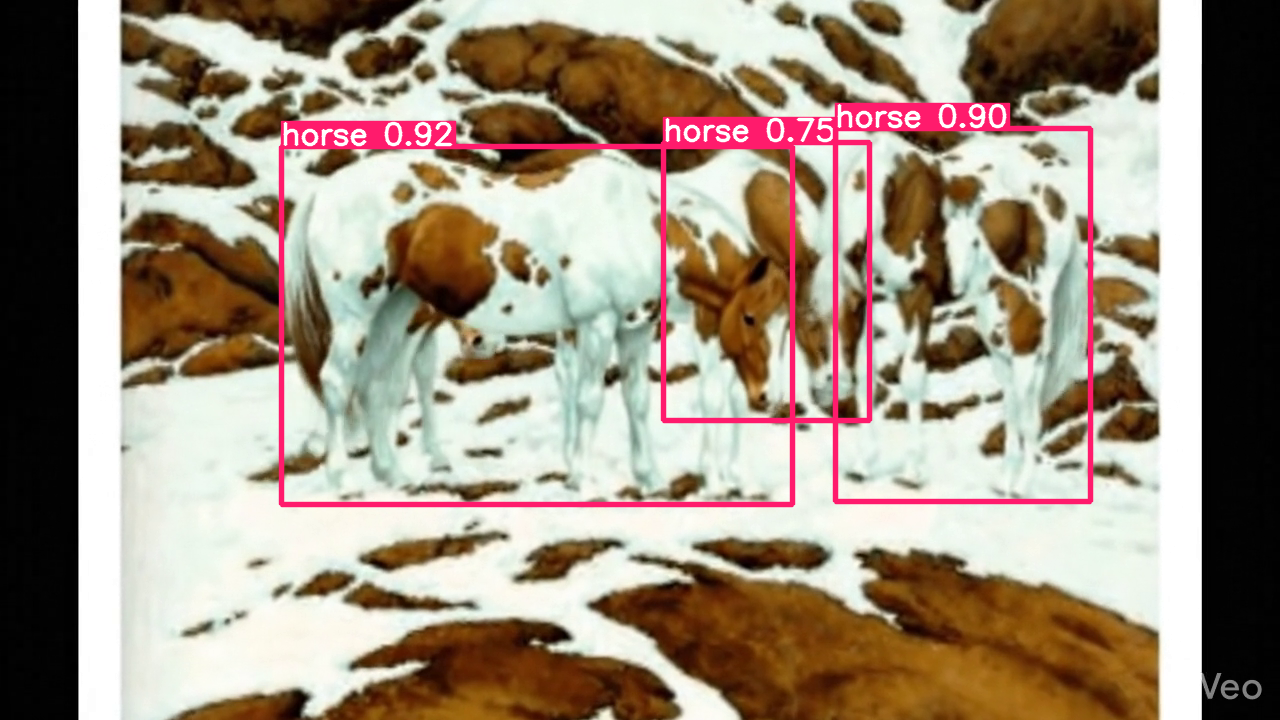

In [ ]:
best_result.show()

In [ ]:
if np.unique(best_classes).shape[0] == 1:
  if len(best_classes) > 1:
    print(f"Objects found in the image: {len(best_classes)} {results[0].names[best_classes[0]]}s")
  else:
    print(f"Object found in the image: {results[0].names[best_classes[0]]}")
else:
  for obj in best_classes:
    print(f"Object found in the image: {results[0].names[obj]}")

Object found in the image: dog


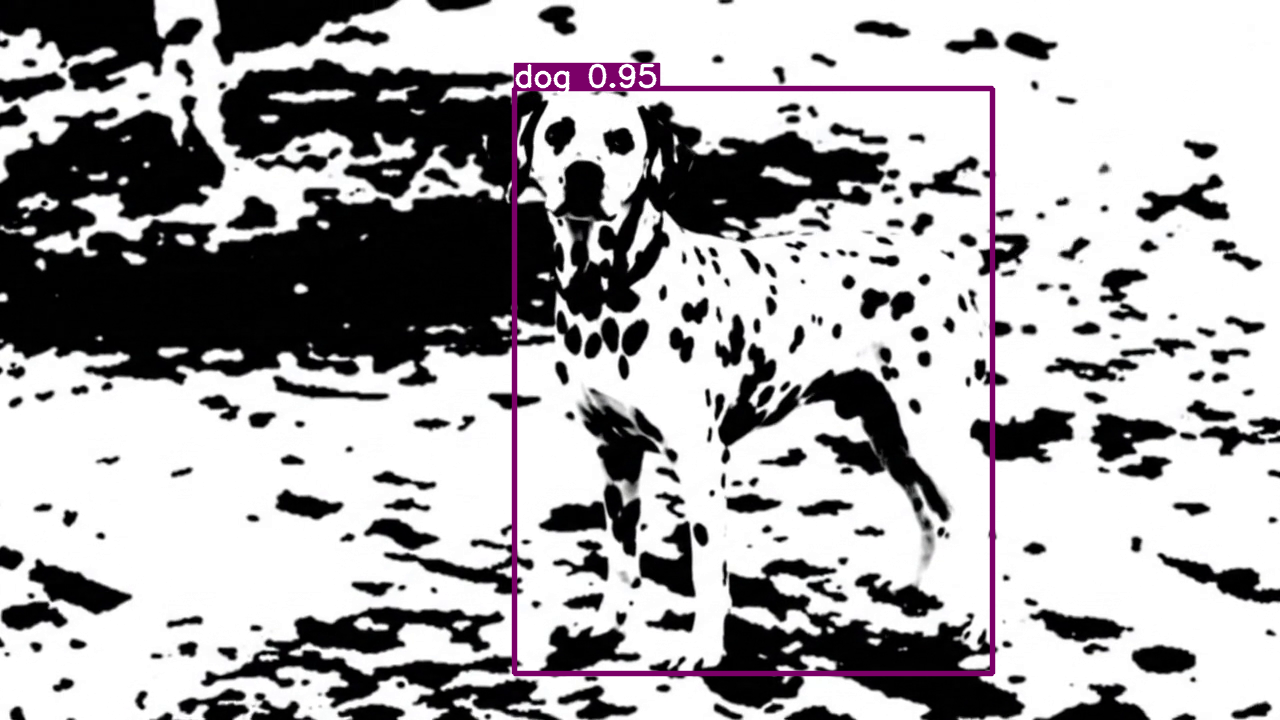

In [ ]:
best_result.show()